In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import ast
import os

# ==============================================================================
# 1. 配置区域 (Configuration)
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# 文件设定
FILE_INFO             = "ParticipantsInfo.xlsx"
DIR_PARTICIPANTS_DATA = "ParticipantsData"
FILE_PINGPANG         = "pingpang.csv"
FILE_TENNIS           = "tennis.csv"

# Excel 总表列名
COL_INFO_NO       = "No."
COL_INFO_LABEL    = "Label"
COL_INFO_FILENAME = "PicoFile"

# CSV 数据文件列名
COL_DATA_VIDEONAME= "videoName"   # 每一行对应的视频名
COL_DATA_EYEDATA  = "EyeData"     # 每一行对应的眼动数据串

# 物理参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# ==============================================================================
# 2. 核心功能
# ==============================================================================

def load_ball_library():
    """ 加载并处理所有球的轨迹 """
    print(">>> [Step 1] 加载球轨迹库...")
    path_pp = os.path.join(BASE_DIR, FILE_PINGPANG)
    path_tn = os.path.join(BASE_DIR, FILE_TENNIS)

    if not os.path.exists(path_pp) or not os.path.exists(path_tn):
        print("错误: 找不到球轨迹文件"); return {}

    # 合并、解析
    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan)
    )

    # 坐标转换 (Video Space -> Screen Space)
    scale_x = SCREEN_W / VIDEO_W
    scale_y = SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * scale_x - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * scale_y - (SCREEN_H / 2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    # 构建库
    df_clean = df_all.dropna(subset=['ball_x', 'ball_y'])
    ball_lib = {k: v for k, v in df_clean.groupby('video_name')}
    print(f"    轨迹库加载完成: 包含 {len(ball_lib)} 个不同视频的数据。")
    return ball_lib

def process_single_row(eye_data_str, eye_fps):
    """ 解析单行 EyeData 字符串，返回 DataFrame """
    if not isinstance(eye_data_str, str): return None

    frames = eye_data_str.split(';')
    parsed_data = []
    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue
        vals = frame.strip().split()
        # 转换为 float
        row = [float(v) if v != 'NaN' else np.nan for v in vals]
        if len(row) >= 2: parsed_data.append(row[:2]) # 取 x, y

    df = pd.DataFrame(parsed_data, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / eye_fps)
    return df

# ==============================================================================
# 3. 主程序 (支持单文件多视频)
# ==============================================================================

def main():
    # 1. 准备球数据
    ball_lib = load_ball_library()
    if not ball_lib: return

    # 2. 读取人员名单
    info_path = os.path.join(BASE_DIR, FILE_INFO)
    print(f">>> [Step 2] 读取名单: {info_path}")
    try:
        df_info = pd.read_excel(info_path, dtype={COL_INFO_NO: str})
    except Exception as e:
        print(f"读取Excel失败: {e}"); return

    final_results = []

    print("\n>>> [Step 3] 开始遍历每位受试者及每个观看记录...")

    # --- 第一层循环：遍历受试者 (Excel中的每一行) ---
    for _, info_row in df_info.iterrows():
        no_id = info_row.get(COL_INFO_NO)
        label = info_row.get(COL_INFO_LABEL)
        fname = info_row.get(COL_INFO_FILENAME)

        if pd.isna(fname): continue
        if pd.isna(no_id): no_id = "Unknown"

        # 构造路径
        clean_fname = str(fname).strip()
        if not clean_fname.lower().endswith('.csv'): clean_fname += ".csv"
        full_path = os.path.join(BASE_DIR, DIR_PARTICIPANTS_DATA, clean_fname)

        # 检查文件
        if not os.path.exists(full_path):
            print(f"[{no_id}] 文件缺失: {clean_fname}")
            final_results.append({
                'No.': no_id, 'Label': label, 'File': clean_fname,
                'Status': 'File Not Found'
            })
            continue

        # 读取受试者的 CSV 数据文件
        try:
            df_participant = pd.read_csv(full_path)
        except Exception as e:
            print(f"[{no_id}] 读取CSV失败: {e}")
            final_results.append({'No.': no_id, 'Status': 'Read Error'})
            continue

        # 检查必要列
        if COL_DATA_VIDEONAME not in df_participant.columns or COL_DATA_EYEDATA not in df_participant.columns:
            print(f"[{no_id}] 列名缺失 (需要 {COL_DATA_VIDEONAME} 和 {COL_DATA_EYEDATA})")
            continue

        # --- 第二层循环：遍历该受试者观看的每一个视频 (CSV中的每一行) ---
        # 即使文件里只有一行，这里也会正常工作
        for row_idx, data_row in df_participant.iterrows():
            video_name = str(data_row[COL_DATA_VIDEONAME]).strip()
            eye_str    = data_row[COL_DATA_EYEDATA]

            # 初始化结果字典
            res_entry = {
                'No.': no_id,
                'Label': label,
                'Video': video_name,     # 当前这一行对应的视频
                'Row_Index': row_idx,    # 记录这是第几行数据
                'Mean_Error': np.nan,
                'Valid_Frames': 0,
                'Status': 'Processing',
                'File': clean_fname
            }

            # 1. 检查视频库
            if video_name not in ball_lib:
                res_entry['Status'] = 'Video Not Found in Library'
                final_results.append(res_entry)
                # 仅打印警告，不中断，继续下一行
                # print(f"[{no_id}] 视频缺失: {video_name}")
                continue

            # 2. 解析眼动数据
            df_eye = process_single_row(eye_str, EYE_FPS)
            if df_eye is None or df_eye.empty:
                res_entry['Status'] = 'Empty/Invalid EyeData'
                final_results.append(res_entry)
                continue

            # 3. 对齐与计算 (Interp1d)
            df_ball = ball_lib[video_name]

            # 时间对齐函数
            f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
            f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

            # 计算预测位置
            df_eye['ball_x_pred'] = f_x(df_eye['time'])
            df_eye['ball_y_pred'] = f_y(df_eye['time'])

            # 计算欧氏距离
            dists = np.sqrt(
                (df_eye['gaze_x'] - df_eye['ball_x_pred'])**2 +
                (df_eye['gaze_y'] - df_eye['ball_y_pred'])**2
            )

            mean_err = dists.mean() # 自动归一化
            valid_count = dists.count()

            # 4. 记录结果
            res_entry['Mean_Error'] = mean_err
            res_entry['Valid_Frames'] = valid_count
            res_entry['Status'] = 'Success'
            final_results.append(res_entry)

            print(f"[{no_id}] 行{row_idx} | 视频:{video_name} | 误差:{mean_err:.2f} | 帧数:{valid_count}")

    # 4. 保存最终报告
    out_file = os.path.join(BASE_DIR, "_Analysis_Report_MultiVideo.xlsx")
    df_res = pd.DataFrame(final_results)

    # 排序列
    cols = ['No.', 'Label', 'Video', 'Mean_Error', 'Valid_Frames', 'Row_Index', 'Status', 'File']
    df_res = df_res[[c for c in cols if c in df_res.columns]]

    df_res.to_excel(out_file, index=False)
    print(f"\n>>> 分析完成！报告已生成: {out_file}")
    print(">>> 注意: 同一个 No. 可能对应多行记录 (如果他看了多个视频)")

if __name__ == "__main__":
    main()


>>> [Step 1] 加载球轨迹库...
    轨迹库加载完成: 包含 22 个不同视频的数据。
>>> [Step 2] 读取名单: C:\Users\81026\Desktop\BallGameWatching\ParticipantsInfo.xlsx

>>> [Step 3] 开始遍历每位受试者及每个观看记录...
[24070902] 行0 | 视频:w17 | 误差:234.25 | 帧数:928
[24070902] 行1 | 视频:w22 | 误差:269.75 | 帧数:957
[24070902] 行2 | 视频:w16 | 误差:285.19 | 帧数:1266
[24070902] 行3 | 视频:w13 | 误差:322.66 | 帧数:820
[24070902] 行4 | 视频:p5 | 误差:219.44 | 帧数:450
[24070902] 行5 | 视频:p8 | 误差:225.49 | 帧数:590
[24070902] 行6 | 视频:p2 | 误差:220.64 | 帧数:572
[24070902] 行7 | 视频:p14 | 误差:190.80 | 帧数:775
[24070902] 行8 | 视频:w8 | 误差:285.97 | 帧数:798
[24070902] 行9 | 视频:w18 | 误差:273.73 | 帧数:966
[24070902] 行10 | 视频:w17 | 误差:259.08 | 帧数:901
[24070902] 行11 | 视频:w20 | 误差:285.52 | 帧数:1297
[24070902] 行12 | 视频:p19 | 误差:228.58 | 帧数:579
[24070902] 行13 | 视频:p8 | 误差:185.60 | 帧数:561
[24070902] 行14 | 视频:p4 | 误差:184.96 | 帧数:523
[24070902] 行15 | 视频:p5 | 误差:214.64 | 帧数:411
[24070902] 行32 | 视频:w10 | 误差:216.21 | 帧数:673
[24070902] 行33 | 视频:w12 | 误差:314.39 | 帧数:934
[24070902] 行34 | 视频:w17 | 误差:237.87 | 

In [19]:

import pandas as pd
import numpy as np
import os
import ast
from scipy.interpolate import interp1d

# ==============================================================================
# 1. 输入配置区域 (INPUT CONFIGURATION)
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# --- 核心设置：数据清洗阈值 ---
# 含义：保留 (均值 - N倍标准差) 到 (均值 + N倍标准差) 之间的数据
# 建议值：2.0 (严格清洗), 3.0 (宽松清洗, 仅剔除极端值)
OUTLIER_THRESHOLD_STD =100

# 文件设定
FILE_INFO             = "ParticipantsInfo.xlsx"
DIR_PARTICIPANTS_DATA = "ParticipantsData"
FILE_PINGPANG         = "pingpang.csv"
FILE_TENNIS           = "tennis.csv"

# Excel 总表列名
COL_INFO_NO       = "No."
COL_INFO_LABEL    = "Label"
COL_INFO_FILENAME = "PicoFile"

# CSV 数据文件列名
COL_DATA_VIDEONAME= "videoName"
COL_DATA_EYEDATA  = "EyeData"

# 物理参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# ==============================================================================
# 2. 核心工具函数
# ==============================================================================

def load_ball_library():
    # 加载球轨迹 (保持不变)
    path_pp = os.path.join(BASE_DIR, FILE_PINGPANG)
    path_tn = os.path.join(BASE_DIR, FILE_TENNIS)
    if not os.path.exists(path_pp) or not os.path.exists(path_tn): return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))

    scale_x = SCREEN_W / VIDEO_W
    scale_y = SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * scale_x - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * scale_y - (SCREEN_H / 2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    df_clean = df_all.dropna(subset=['ball_x', 'ball_y'])
    return {k: v for k, v in df_clean.groupby('video_name')}

def process_single_row(eye_data_str, eye_fps):
    # 解析眼动数据 (保持不变)
    if not isinstance(eye_data_str, str): return None
    frames = eye_data_str.split(';')
    parsed_data = []
    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue
        vals = frame.strip().split()
        row = [float(v) if v != 'NaN' else np.nan for v in vals]
        if len(row) >= 2: parsed_data.append(row[:2])

    df = pd.DataFrame(parsed_data, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / eye_fps)
    return df

# ==============================================================================
# 3. 新增：基于均值和标准差的清洗算法 (Mean & Std Method)
# ==============================================================================

def clean_outliers_by_mean_std(df_details):
    """
    使用 (Mean +/- N * Std) 方法剔除异常值。
    针对每个 Label 组独立计算均值和标准差。
    """
    print('\n' * 2)
    print("=" * 60)
    print(f">>> [Step 3.5] 数据清洗: 剔除远离均值的数据 (阈值: {OUTLIER_THRESHOLD_STD} 倍标准差)")
    print("=" * 60)

    # 仅处理状态为 Success 的数据
    valid_df = df_details[df_details['Status'] == 'Success'].copy()

    keep_indices = []
    dropped_info = []

    # 按 Label 分组处理 (HC, AD, MCI 分别计算自己的均值)
    for label, group in valid_df.groupby('Label'):
        if len(group) < 2:
            # 样本太少无法计算标准差，直接保留
            keep_indices.extend(group.index)
            continue

        # 1. 计算该组的均值和标准差
        mean_val = group['Mean_Error'].mean()
        std_val  = group['Mean_Error'].std()

        # 2. 计算保留范围 (上下限)
        # 范围 = [均值 - N*SD, 均值 + N*SD]
        lower_bound = mean_val - (OUTLIER_THRESHOLD_STD * std_val)
        upper_bound = mean_val + (OUTLIER_THRESHOLD_STD * std_val)

        # 3. 筛选数据
        mask = (group['Mean_Error'] >= lower_bound) & (group['Mean_Error'] <= upper_bound)

        # 记录要保留的行索引
        keep_indices.extend(group[mask].index)

        # 记录被剔除的数据 (方便打印日志)
        outliers = group[~mask]
        if not outliers.empty:
            for _, row in outliers.iterrows():
                dropped_info.append(
                    f"剔除 [{label}] No.{row['No.']} (Video:{row['Video']}): "
                    f"误差 {row['Mean_Error']:.1f} "
                    f"(该组范围: {lower_bound:.1f} ~ {upper_bound:.1f}, Mean:{mean_val:.1f})"
                )

    # 打印清洗报告
    if dropped_info:
        for info in dropped_info:
            print(info)
        print(f"--- 共剔除 {len(dropped_info)} 条偏离均值过远的数据 ---")
    else:
        print("--- 数据质量良好，未发现超过阈值的异常点 ---")

    # 返回清洗后的 DataFrame (合并原本失败的行 + 清洗后成功的行)
    original_indices = set(df_details.index)
    success_indices = set(valid_df.index)
    keep_indices_set = set(keep_indices)

    final_indices = (original_indices - success_indices) | keep_indices_set

    return df_details.loc[sorted(list(final_indices))]

# ==============================================================================
# 4. 统计计算函数 (对清洗后的数据进行统计)
# ==============================================================================

def calculate_metrics(df_cleaned):
    # 1. 个人统计 (Person Stats)
    person_stats = []
    # 必须基于清洗后的数据计算
    valid_df = df_cleaned[df_cleaned['Status'] == 'Success']

    grouped = valid_df.groupby(['No.', 'Label'])
    for (pid, label), group in grouped:
        # 加权平均: 总误差距离 / 总帧数
        total_err_mass = (group['Mean_Error'] * group['Valid_Frames']).sum()
        total_frames = group['Valid_Frames'].sum()
        mean_err = total_err_mass / total_frames if total_frames > 0 else np.nan

        person_stats.append({'No.': pid, 'Label': label, 'Person_Mean_Error': mean_err})

    df_person = pd.DataFrame(person_stats)

    # 2. 组别统计 (Group Stats)
    df_person_valid = df_person.dropna(subset=['Person_Mean_Error'])
    if df_person_valid.empty:
        return df_person, pd.DataFrame()

    # 统计 均值、标准差、人数
    label_stats = df_person_valid.groupby('Label')['Person_Mean_Error'].agg(['mean', 'std', 'count']).reset_index()
    label_stats.columns = ['Label', 'Group_Mean_Error', 'Std_Dev', 'Count']

    return df_person, label_stats

# ==============================================================================
# 5. 主程序
# ==============================================================================

def main():
    ball_lib = load_ball_library()
    if not ball_lib: return

    info_path = os.path.join(BASE_DIR, FILE_INFO)
    try:
        df_info = pd.read_excel(info_path, dtype={COL_INFO_NO: str})
    except Exception as e:
        print(f"读取Excel失败: {e}"); return

    detailed_results = []
    print("\n>>> [Step 1-3] 详细数据处理与初步计算...")

    # --- 逐行处理 ---
    for _, info_row in df_info.iterrows():
        no_id = info_row.get(COL_INFO_NO)
        label = info_row.get(COL_INFO_LABEL)
        fname = info_row.get(COL_INFO_FILENAME)

        if pd.isna(fname): continue
        if pd.isna(no_id): no_id = "Unknown"

        clean_fname = str(fname).strip()
        if not clean_fname.lower().endswith('.csv'): clean_fname += ".csv"
        full_path = os.path.join(BASE_DIR, DIR_PARTICIPANTS_DATA, clean_fname)

        if not os.path.exists(full_path):
            continue

        try:
            df_part = pd.read_csv(full_path)
            if COL_DATA_VIDEONAME not in df_part.columns or COL_DATA_EYEDATA not in df_part.columns: continue

            for row_idx, data_row in df_part.iterrows():
                video_name = str(data_row[COL_DATA_VIDEONAME]).strip()
                eye_str    = data_row[COL_DATA_EYEDATA]

                res = {'No.': no_id, 'Label': label, 'Video': video_name, 'Status': 'Fail', 'Mean_Error': np.nan, 'Valid_Frames': 0}

                if video_name in ball_lib:
                    df_eye = process_single_row(eye_str, EYE_FPS)
                    if df_eye is not None and not df_eye.empty:
                        df_ball = ball_lib[video_name]
                        f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
                        f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

                        df_eye['bx'] = f_x(df_eye['time'])
                        df_eye['by'] = f_y(df_eye['time'])
                        dists = np.sqrt((df_eye['gaze_x'] - df_eye['bx'])**2 + (df_eye['gaze_y'] - df_eye['by'])**2)

                        res['Mean_Error'] = dists.mean()
                        res['Valid_Frames'] = dists.count()
                        res['Status'] = 'Success'

                        # 实时输出
                        print(f"[{no_id}] 行{row_idx:<2} | 视频:{video_name:<3} | 误差:{res['Mean_Error']:.2f} | 帧数:{res['Valid_Frames']}")

                detailed_results.append(res)
        except Exception:
            pass

    # --- 数据转换 ---
    df_details = pd.DataFrame(detailed_results)
    if df_details.empty: print("没有有效数据"); return

    # --- 新增步骤: 基于均值和标准差清洗 ---
    df_cleaned = clean_outliers_by_mean_std(df_details)

    # --- 统计计算 (基于清洗后的数据) ---
    df_person, df_label = calculate_metrics(df_cleaned)

    # --- 最终输出 ---
    print('\n' * 3)
    print("=" * 40)
    print("每个人 (By Person) 的综合平均误差 [清洗后]")
    print("=" * 40)
    print(f"{'No.':<15} {'Label':<10} {'Mean_Error':<15}")
    print("-" * 40)

    for _, row in df_person.iterrows():
        err_str = f"{row['Person_Mean_Error']:.2f}" if not pd.isna(row['Person_Mean_Error']) else "NaN"
        print(f"{row['No.']:<15} {row['Label']:<10} {err_str:<15}")

    print('\n' * 3)
    print("=" * 40)
    print("标签组 (By Group) 的综合平均误差 [清洗后]")
    print("=" * 40)
    print(f"{'Label':<10} {'Mean':<10} {'Std':<10} {'Count':<5}")
    print("-" * 40)

    if not df_label.empty:
        for _, row in df_label.iterrows():
            print(f"{row['Label']:<10} {row['Group_Mean_Error']:.2f}      {row['Std_Dev']:.2f}      {int(row['Count'])}")

if __name__ == "__main__":
    main()



>>> [Step 1-3] 详细数据处理与初步计算...
[24070902] 行0  | 视频:w17 | 误差:234.25 | 帧数:928
[24070902] 行1  | 视频:w22 | 误差:269.75 | 帧数:957
[24070902] 行2  | 视频:w16 | 误差:285.19 | 帧数:1266
[24070902] 行3  | 视频:w13 | 误差:322.66 | 帧数:820
[24070902] 行4  | 视频:p5  | 误差:219.44 | 帧数:450
[24070902] 行5  | 视频:p8  | 误差:225.49 | 帧数:590
[24070902] 行6  | 视频:p2  | 误差:220.64 | 帧数:572
[24070902] 行7  | 视频:p14 | 误差:190.80 | 帧数:775
[24070902] 行8  | 视频:w8  | 误差:285.97 | 帧数:798
[24070902] 行9  | 视频:w18 | 误差:273.73 | 帧数:966
[24070902] 行10 | 视频:w17 | 误差:259.08 | 帧数:901
[24070902] 行11 | 视频:w20 | 误差:285.52 | 帧数:1297
[24070902] 行12 | 视频:p19 | 误差:228.58 | 帧数:579
[24070902] 行13 | 视频:p8  | 误差:185.60 | 帧数:561
[24070902] 行14 | 视频:p4  | 误差:184.96 | 帧数:523
[24070902] 行15 | 视频:p5  | 误差:214.64 | 帧数:411
[24070902] 行32 | 视频:w10 | 误差:216.21 | 帧数:673
[24070902] 行33 | 视频:w12 | 误差:314.39 | 帧数:934
[24070902] 行34 | 视频:w17 | 误差:237.87 | 帧数:898
[24070902] 行35 | 视频:w22 | 误差:291.75 | 帧数:924
[24070902] 行36 | 视频:p10 | 误差:240.12 | 帧数:475
[24070902] 行37 | 视频:p5

In [24]:
import pandas as pd
import numpy as np
import os
import ast
import glob
from scipy.interpolate import interp1d

# ==============================================================================
# 1. 输入配置区域
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# --- 数据清洗阈值 ---
# 建议保持 3.0 (宽松模式)，保留更多视频样本
OUTLIER_THRESHOLD_STD = 2.0

# 文件设定
FILE_INFO             = "ParticipantsInfo.xlsx"
DIR_PARTICIPANTS_DATA = "ParticipantsData"
FILE_PINGPANG         = "pingpang.csv"
FILE_TENNIS           = "tennis.csv"

# Excel 列名
COL_INFO_FILENAME = "PicoFile"
COL_INFO_LABEL    = "Label"
COL_INFO_NO       = "No."

# CSV 数据列名
COL_DATA_VIDEONAME= "videoName"
COL_DATA_EYEDATA  = "EyeData"

# 物理参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# ==============================================================================
# 2. 核心工具函数
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PINGPANG)
    path_tn = os.path.join(BASE_DIR, FILE_TENNIS)
    if not os.path.exists(path_pp) or not os.path.exists(path_tn): return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))

    scale_x = SCREEN_W / VIDEO_W
    scale_y = SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * scale_x - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * scale_y - (SCREEN_H / 2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    df_clean = df_all.dropna(subset=['ball_x', 'ball_y'])
    return {k: v for k, v in df_clean.groupby('video_name')}

def process_single_row(eye_data_str, eye_fps):
    if not isinstance(eye_data_str, str): return None
    frames = eye_data_str.split(';')
    parsed_data = []
    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue
        vals = frame.strip().split()
        row = [float(v) if v != 'NaN' else np.nan for v in vals]
        if len(row) >= 2: parsed_data.append(row[:2])

    df = pd.DataFrame(parsed_data, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / eye_fps)
    return df

def get_label_info_map():
    info_path = os.path.join(BASE_DIR, FILE_INFO)
    if not os.path.exists(info_path): return {}
    try:
        df_info = pd.read_excel(info_path, dtype={COL_INFO_NO: str})
        info_map = {}
        for _, row in df_info.iterrows():
            fname = row.get(COL_INFO_FILENAME)
            if pd.isna(fname): continue
            clean_fname = str(fname).strip()
            if not clean_fname.lower().endswith('.csv'): clean_fname += ".csv"
            info_map[clean_fname] = {
                'Label': row.get(COL_INFO_LABEL, 'Unknown'),
                'No': row.get(COL_INFO_NO, 'Unknown')
            }
        return info_map
    except Exception: return {}

# ==============================================================================
# 3. 数据清洗 (基于视频级数据)
# ==============================================================================

def clean_outliers_loose(df_details):
    print('\n' * 2)
    print("=" * 60)
    print(f">>> [Step 3.5] 数据清洗 (阈值: {OUTLIER_THRESHOLD_STD} STD)")
    print("=" * 60)

    # 只保留处理成功的视频记录
    valid_df = df_details[df_details['Status'] == 'Success'].copy()
    keep_indices = []

    # 按 Label 分组清洗
    for label, group in valid_df.groupby('Label'):
        if len(group) < 3 or label == 'Unknown':
            keep_indices.extend(group.index)
            continue

        mean_val = group['Mean_Error'].mean()
        std_val  = group['Mean_Error'].std()

        lower = mean_val - (OUTLIER_THRESHOLD_STD * std_val)
        upper = mean_val + (OUTLIER_THRESHOLD_STD * std_val)

        mask = (group['Mean_Error'] >= lower) & (group['Mean_Error'] <= upper)
        keep_indices.extend(group[mask].index)

        outliers = group[~mask]
        if not outliers.empty:
            for _, row in outliers.iterrows():
                # 这里打印的是 Video 级别的信息
                print(f"剔除 [{label}] File:{row['File']} Video:{row['Video']} (Err:{row['Mean_Error']:.1f} 超出范围)")

    original_indices = set(df_details.index)
    success_indices = set(valid_df.index)
    keep_indices_set = set(keep_indices)

    final_indices = (original_indices - success_indices) | keep_indices_set
    return df_details.loc[sorted(list(final_indices))]

# ==============================================================================
# 4. 统计计算 (重点修改区域)
# ==============================================================================

def calculate_metrics(df_cleaned):
    # 获取所有有效的视频记录
    valid_video_data = df_cleaned[df_cleaned['Status'] == 'Success'].copy()

    # --- 1. 个人统计 (Person Stats) ---
    # 这里依然需要聚合一下，方便看每个人的表现
    person_stats = []
    grouped_person = valid_video_data.groupby(['No.', 'Label', 'File'])

    for (pid, label, fname), group in grouped_person:
        # 加权计算该人的平均分
        total_err = (group['Mean_Error'] * group['Valid_Frames']).sum()
        total_frames = group['Valid_Frames'].sum()
        mean_err = total_err / total_frames if total_frames > 0 else np.nan

        person_stats.append({
            'No.': pid, 'Label': label, 'File': fname, 'Person_Mean_Error': mean_err,
            'Video_Count': len(group) # 这个人看了几个视频
        })
    df_person = pd.DataFrame(person_stats)

    # --- 2. 标签组统计 (Label Stats) - 基于有效视频数 ---
    if valid_video_data.empty:
        return df_person, pd.DataFrame(), {}

    # 关键修改：直接基于 valid_video_data (视频级数据) 进行 groupby
    # count 这里统计的是“行数”，即视频的数量
    label_stats = valid_video_data.groupby('Label')['Mean_Error'].agg(['mean', 'var', 'std', 'count']).reset_index()
    label_stats.columns = ['Label', 'Mean', 'Variance', 'Std_Dev', 'Video_Count']

    # --- 3. 总体统计 (Global Stats) - 基于有效视频数 ---
    global_stats = {
        'Total_Video_Count': valid_video_data['Mean_Error'].count(),
        'Global_Mean':       valid_video_data['Mean_Error'].mean(),
        'Global_Variance':   valid_video_data['Mean_Error'].var(),
        'Global_Std_Dev':    valid_video_data['Mean_Error'].std()
    }

    return df_person, label_stats, global_stats

# ==============================================================================
# 5. 主程序
# ==============================================================================

def main():
    ball_lib = load_ball_library()
    if not ball_lib: print("错误：无法加载球轨迹"); return

    info_map = get_label_info_map()
    data_dir = os.path.join(BASE_DIR, DIR_PARTICIPANTS_DATA)
    if not os.path.exists(data_dir): print("错误：找不到数据文件夹"); return

    all_files = glob.glob(os.path.join(data_dir, "*.csv"))
    print(f"\n>>> 扫描到 {len(all_files)} 个文件，开始处理...")

    detailed_results = []

    for file_path in all_files:
        file_name = os.path.basename(file_path)

        # 1. 确定标签 (含 MMD 自动识别补丁)
        if file_name in info_map:
            no_id = info_map[file_name]['No']
            label = info_map[file_name]['Label']
        else:
            # 自动猜测逻辑
            name_part = os.path.splitext(file_name)[0].upper()
            label = 'Unknown'
            if 'HC' in name_part: label = 'HC'
            elif 'AD' in name_part: label = 'AD'
            elif 'MCI' in name_part: label = 'MCI'
            elif 'MMD' in name_part: label = 'MMD' # <--- 确保识别 MMD

            parts = name_part.split('_')
            no_id = parts[0] if len(parts) > 0 else 'Unknown'

        # 2. 处理文件
        try:
            df_part = pd.read_csv(file_path)
            if COL_DATA_VIDEONAME not in df_part.columns or COL_DATA_EYEDATA not in df_part.columns:
                continue

            for row_idx, data_row in df_part.iterrows():
                video_name = str(data_row[COL_DATA_VIDEONAME]).strip()
                eye_str    = data_row[COL_DATA_EYEDATA]

                res = {
                    'No.': no_id, 'Label': label, 'File': file_name,
                    'Video': video_name, 'Status': 'Fail',
                    'Mean_Error': np.nan, 'Valid_Frames': 0
                }

                if video_name in ball_lib:
                    df_eye = process_single_row(eye_str, EYE_FPS)
                    if df_eye is not None and not df_eye.empty:
                        df_ball = ball_lib[video_name]
                        f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
                        f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

                        df_eye['bx'] = f_x(df_eye['time'])
                        df_eye['by'] = f_y(df_eye['time'])
                        dists = np.sqrt((df_eye['gaze_x'] - df_eye['bx'])**2 + (df_eye['gaze_y'] - df_eye['by'])**2)

                        mean_err = dists.mean()
                        count = dists.count()

                        if count > 0:
                            res['Mean_Error'] = mean_err
                            res['Valid_Frames'] = count
                            res['Status'] = 'Success'
                            # print(f"[{no_id}] {label} | V:{video_name} | Err:{mean_err:.1f}")

                detailed_results.append(res)
        except Exception: pass

    # --- 统计输出 ---
    df_details = pd.DataFrame(detailed_results)
    if df_details.empty: print("无有效数据"); return

    # 清洗
    df_cleaned = clean_outliers_loose(df_details)

    # 计算
    df_person, df_label, global_stats = calculate_metrics(df_cleaned)

    # 输出 1: 个人均值 (保留以便查阅)
    print('\n' * 3)
    print("=" * 60)
    print("每个人 (By Person) 的平均误差")
    print("=" * 60)
    print(f"{'No.':<15} {'Label':<10} {'File':<25} {'Mean_Error':<15} {'Videos':<5}")
    print("-" * 60)
    for _, row in df_person.iterrows():
        err_str = f"{row['Person_Mean_Error']:.2f}" if not pd.isna(row['Person_Mean_Error']) else "NaN"
        print(f"{row['No.']:<15} {row['Label']:<10} {row['File']:<25} {err_str:<15} {int(row['Video_Count'])}")

    # 输出 2: 组别统计 (Count = 视频数)
    print('\n' * 3)
    print("=" * 70)
    print("标签组 (By Group) 统计 [Count = 有效视频数]")
    print("=" * 70)
    print(f"{'Label':<10} {'Mean':<10} {'Variance':<10} {'Std':<10} {'Count':<5}")
    print("-" * 70)
    if not df_label.empty:
        for _, row in df_label.iterrows():
            print(f"{row['Label']:<10} {row['Mean']:.2f}      {row['Variance']:.2f}      {row['Std_Dev']:.2f}      {int(row['Video_Count'])}")

    # 输出 3: 总体统计 (Count = 视频数)
    print('\n' * 3)
    print("=" * 40)
    print("所有视频样本 (Total Statistics)")
    print("=" * 40)
    print(f"Total Video Count: {int(global_stats.get('Total_Video_Count', 0))}")
    print(f"Global Mean:       {global_stats.get('Global_Mean', 0):.2f}")
    print(f"Global Variance:   {global_stats.get('Global_Variance', 0):.2f}")
    print(f"Global Std Dev:    {global_stats.get('Global_Std_Dev', 0):.2f}")

if __name__ == "__main__":
    main()



>>> 扫描到 73 个文件，开始处理...



>>> [Step 3.5] 数据清洗 (阈值: 2.0 STD)
剔除 [HC] File:24070904_AD.csv Video:w8 (Err:392.8 超出范围)
剔除 [HC] File:24070904_AD.csv Video:p10 (Err:363.0 超出范围)
剔除 [HC] File:24070906_AD.csv Video:p10 (Err:429.5 超出范围)
剔除 [HC] File:24071008_AD.csv Video:p4 (Err:395.3 超出范围)
剔除 [HC] File:24071008_AD.csv Video:p10 (Err:412.4 超出范围)
剔除 [HC] File:24071512_AD.csv Video:p7 (Err:388.0 超出范围)
剔除 [HC] File:24071615_AD.csv Video:p2 (Err:480.1 超出范围)
剔除 [HC] File:24071618_AD.csv Video:p10 (Err:366.1 超出范围)
剔除 [HC] File:24071721_AD.csv Video:p8 (Err:394.4 超出范围)
剔除 [HC] File:24092001_AD.csv Video:w12 (Err:368.8 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w20 (Err:382.8 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w8 (Err:371.8 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w15 (Err:454.1 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w10 (Err:363.5 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w20 (Err:478.1 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w12 (Err:611.2 超出范围)
剔除 [HC] File:24092105_AD.csv Video:w16 (Err:528.9

开始处理 73 个文件，提取高级特征...

各组特征均值对比 (Feature Comparison)
            Time_Lag_ms  Velocity_Corr  Focus_Rate
Label                                             
HC          -622.093863       0.131665    0.273440
MCI         -585.507246       0.107843    0.283617
MMD         -652.222222       0.073741    0.301312
mildAD      -597.810219       0.178937    0.253877
moderateAD  -574.666667       0.201263    0.328616

结果已保存至 Advanced_Features_Analysis.xlsx


C:\Users\81026\AppData\Local\Temp\ipykernel_146684\478455882.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Time_Lag_ms', data=df_plot, palette="Set3")
C:\Users\81026\AppData\Local\Temp\ipykernel_146684\478455882.py:243: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Velocity_Corr', data=df_plot, palette="Set3")
C:\Users\81026\AppData\Local\Temp\ipykernel_146684\478455882.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Focus_Rate', data=df_plot, palette="Set3")


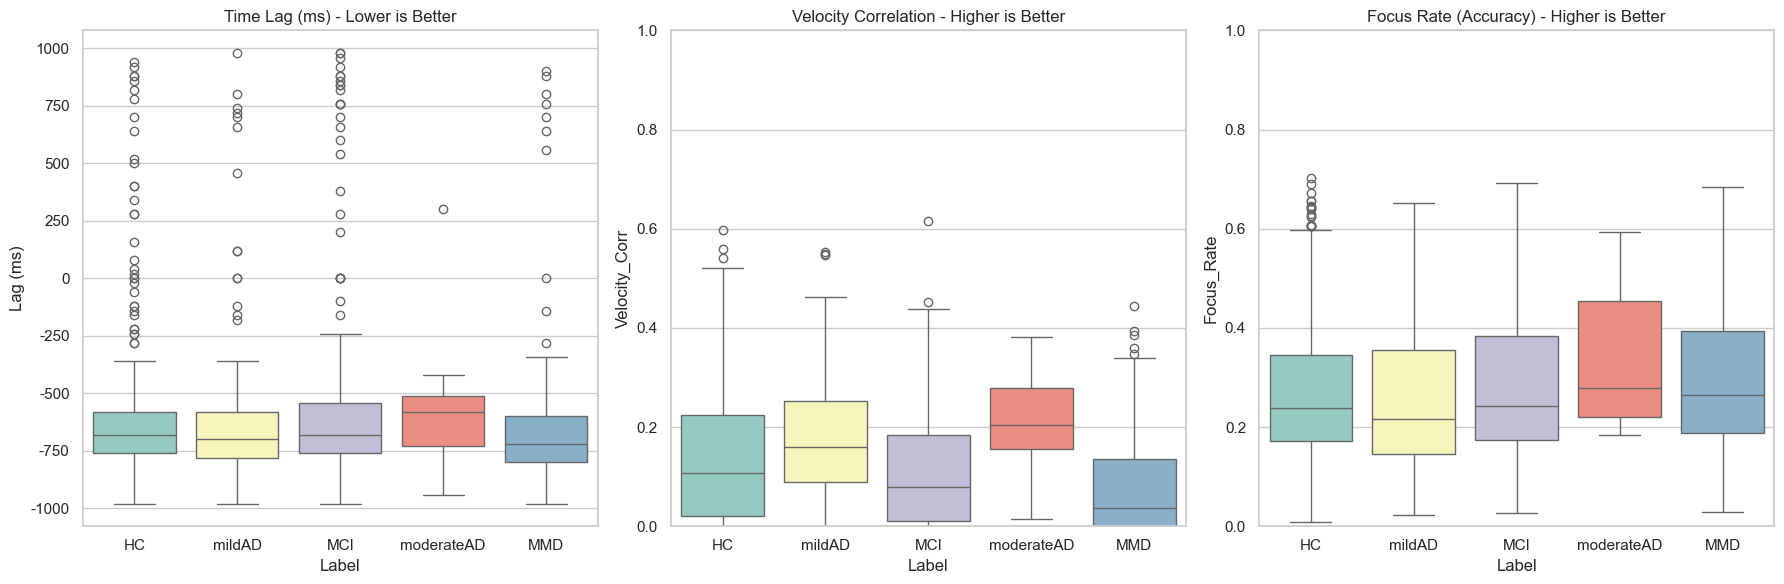

In [44]:
import pandas as pd
import numpy as np
import os
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import correlate

# ==============================================================================
# 1. 配置区域
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# 文件设定
FILE_INFO             = "ParticipantsInfo.xlsx"
DIR_PARTICIPANTS_DATA = "ParticipantsData"
FILE_PINGPANG         = "pingpang.csv"
FILE_TENNIS           = "tennis.csv"

# 参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# 特征计算参数
LAG_SEARCH_RANGE   = 20   # 搜索前后 20帧 (约 +/- 400ms) 的滞后
FOCUS_THRESHOLD_PX = 150  # 误差小于 150px 算作“有效注视”

# ==============================================================================
# 2. 核心工具函数 (加载与基础处理)
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PINGPANG)
    path_tn = os.path.join(BASE_DIR, FILE_TENNIS)
    if not os.path.exists(path_pp) or not os.path.exists(path_tn): return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))

    scale_x = SCREEN_W / VIDEO_W
    scale_y = SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * scale_x - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * scale_y - (SCREEN_H / 2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    df_clean = df_all.dropna(subset=['ball_x', 'ball_y'])
    return {k: v for k, v in df_clean.groupby('video_name')}

def process_single_row(eye_data_str, eye_fps):
    if not isinstance(eye_data_str, str): return None
    frames = eye_data_str.split(';')
    parsed_data = []
    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue
        vals = frame.strip().split()
        row = [float(v) if v != 'NaN' else np.nan for v in vals]
        if len(row) >= 2: parsed_data.append(row[:2])

    df = pd.DataFrame(parsed_data, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / eye_fps)
    return df

def get_label_info_map():
    info_path = os.path.join(BASE_DIR, FILE_INFO)
    if not os.path.exists(info_path): return {}
    try:
        df_info = pd.read_excel(info_path, dtype={"No.": str})
        info_map = {}
        for _, row in df_info.iterrows():
            fname = row.get("PicoFile")
            if pd.isna(fname): continue
            clean_fname = str(fname).strip()
            if not clean_fname.lower().endswith('.csv'): clean_fname += ".csv"
            info_map[clean_fname] = {
                'Label': row.get("Label", 'Unknown'),
                'No': row.get("No.", 'Unknown')
            }
        return info_map
    except Exception: return {}

# ==============================================================================
# 3. 高级特征提取算法 (核心修改部分)
# ==============================================================================

def calculate_advanced_features(df_eye, df_ball):
    """
    计算三个高级特征：
    1. Time_Lag (ms): 滞后时间
    2. Velocity_Corr: 速度相关性
    3. Focus_Rate: 有效注视比率
    """
    # --- 1. 数据对齐与插值 ---
    # 创建插值函数
    f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
    f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

    # 获取每一帧的球位置
    ball_x = f_x(df_eye['time'])
    ball_y = f_y(df_eye['time'])

    # 剔除无效数据 (NaN) 用于计算
    valid_mask = ~np.isnan(ball_x) & ~np.isnan(df_eye['gaze_x'])
    if np.sum(valid_mask) < 50: # 如果有效数据太少，无法计算
        return np.nan, np.nan, np.nan

    g_x, g_y = df_eye.loc[valid_mask, 'gaze_x'].values, df_eye.loc[valid_mask, 'gaze_y'].values
    b_x, b_y = ball_x[valid_mask], ball_y[valid_mask]

    # --- 特征 A: 滞后时间 (Time Lag) ---
    # 使用互相关 (Cross-Correlation) 计算 X 轴方向的最佳偏移
    # 为什么只用X轴？因为乒乓球/网球主要是左右移动，X轴信号最强
    lags = correlate(g_x - np.mean(g_x), b_x - np.mean(b_x), mode='full')
    lag_index = np.argmax(lags)
    # 将索引转换为偏移帧数
    shift_frames = lag_index - (len(g_x) - 1)
    # 转换为毫秒 (负数代表滞后，正数代表超前，通常关注绝对值或负值)
    # 修正逻辑：我们关心的是“眼动比球晚了多少”，通常是正数表示滞后
    time_lag_ms = -shift_frames * (1000 / EYE_FPS)

    # --- 特征 B: 速度相关性 (Velocity Correlation) ---
    # 计算速度 (差分)
    g_vel_x = np.diff(g_x)
    g_vel_y = np.diff(g_y)
    b_vel_x = np.diff(b_x)
    b_vel_y = np.diff(b_y)

    # 合成速度大小
    g_speed = np.sqrt(g_vel_x**2 + g_vel_y**2)
    b_speed = np.sqrt(b_vel_x**2 + b_vel_y**2)

    # 计算相关系数
    if len(g_speed) > 10:
        vel_corr = np.corrcoef(g_speed, b_speed)[0, 1]
    else:
        vel_corr = np.nan

    # --- 特征 C: 有效注视率 (Focus Rate) ---
    dists = np.sqrt((g_x - b_x)**2 + (g_y - b_y)**2)
    # 统计有多少比例的点在阈值范围内
    focus_rate = np.sum(dists < FOCUS_THRESHOLD_PX) / len(dists)

    return time_lag_ms, vel_corr, focus_rate

# ==============================================================================
# 4. 主程序
# ==============================================================================

def main():
    ball_lib = load_ball_library()
    if not ball_lib: print("加载球轨迹失败"); return

    info_map = get_label_info_map()
    data_dir = os.path.join(BASE_DIR, DIR_PARTICIPANTS_DATA)
    all_files = glob.glob(os.path.join(data_dir, "*.csv"))

    print(f"开始处理 {len(all_files)} 个文件，提取高级特征...")

    results = []

    for file_path in all_files:
        file_name = os.path.basename(file_path)

        # 标签识别
        if file_name in info_map:
            no_id, label = info_map[file_name]['No'], info_map[file_name]['Label']
        else:
            name_part = os.path.splitext(file_name)[0].upper()
            label = 'Unknown'
            if 'HC' in name_part: label = 'HC'
            elif 'AD' in name_part: label = 'AD'
            elif 'MCI' in name_part: label = 'MCI'
            elif 'MMD' in name_part: label = 'MMD'
            no_id = name_part.split('_')[0]

        try:
            df_part = pd.read_csv(file_path)
            if "videoName" not in df_part.columns or "EyeData" not in df_part.columns: continue

            for _, data_row in df_part.iterrows():
                video_name = str(data_row["videoName"]).strip()
                eye_str = data_row["EyeData"]

                if video_name in ball_lib:
                    df_eye = process_single_row(eye_str, EYE_FPS)
                    if df_eye is not None and len(df_eye) > 50:
                        df_ball = ball_lib[video_name]

                        # === 调用新的特征计算 ===
                        lag, v_corr, focus = calculate_advanced_features(df_eye, df_ball)

                        # 简单的异常值过滤 (例如 Lag 不可能超过 1000ms)
                        if abs(lag) < 1000:
                            results.append({
                                'Label': label,
                                'No': no_id,
                                'File': file_name,
                                'Time_Lag_ms': lag,       # 越小越好 (接近0)
                                'Velocity_Corr': v_corr,  # 越大越好 (接近1)
                                'Focus_Rate': focus       # 越大越好 (接近1)
                            })
                            # print(f"[{label}] Lag:{lag:.1f}ms | Corr:{v_corr:.2f} | Focus:{focus:.2f}")

        except Exception: pass

    # --- 结果分析与绘图 ---
    df_res = pd.DataFrame(results)
    if df_res.empty: print("无有效数据"); return

    # 剔除 Unknown 以便画图清晰
    df_plot = df_res[df_res['Label'] != 'Unknown'].copy()

    print("\n" + "="*60)
    print("各组特征均值对比 (Feature Comparison)")
    print("="*60)
    # 按标签分组计算均值
    summary = df_plot.groupby('Label')[['Time_Lag_ms', 'Velocity_Corr', 'Focus_Rate']].mean()
    print(summary)

    # 保存结果
    df_res.to_excel(os.path.join(BASE_DIR, "Advanced_Features_Analysis.xlsx"), index=False)
    print(f"\n结果已保存至 Advanced_Features_Analysis.xlsx")

    # === 画图：箱线图 (Boxplot) ===
    # 这张图最能体现“显著性”
    plt.figure(figsize=(18, 6))

    # 设置绘图风格
    sns.set(style="whitegrid")

    # 子图1: 滞后时间
    plt.subplot(1, 3, 1)
    sns.boxplot(x='Label', y='Time_Lag_ms', data=df_plot, palette="Set3")
    plt.title('Time Lag (ms) - Lower is Better')
    plt.ylabel('Lag (ms)')

    # 子图2: 速度相关性
    plt.subplot(1, 3, 2)
    sns.boxplot(x='Label', y='Velocity_Corr', data=df_plot, palette="Set3")
    plt.title('Velocity Correlation - Higher is Better')
    plt.ylim(0, 1) # 相关性通常在 0-1 之间

    # 子图3: 有效注视率
    plt.subplot(1, 3, 3)
    sns.boxplot(x='Label', y='Focus_Rate', data=df_plot, palette="Set3")
    plt.title('Focus Rate (Accuracy) - Higher is Better')
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


>>> 正在初始化高级算法模块...
>>> 开始对 73 个受试者文件进行深度特征提取...

各组病理特征均值对比表
                速度增益  样本熵(混乱度)      豪斯多夫距离
Label                                     
HC          1.542555  0.649308  269.656338
MCI         1.283169  0.628482  267.691936
MMD         1.384056  0.677538  272.988254
mildAD      1.878813  0.712562  281.393029
moderateAD  1.851475  0.832385  254.699055


C:\Users\81026\AppData\Local\Temp\ipykernel_146684\869178005.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='速度增益', data=df_plot, ax=axes[0], palette="Set2")
C:\Users\81026\AppData\Local\Temp\ipykernel_146684\869178005.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='样本熵(混乱度)', data=df_plot, ax=axes[1], palette="Set2")
C:\Users\81026\AppData\Local\Temp\ipykernel_146684\869178005.py:267: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='豪斯多夫距离', data=df_plot, ax=axes[2], palette="Set2")


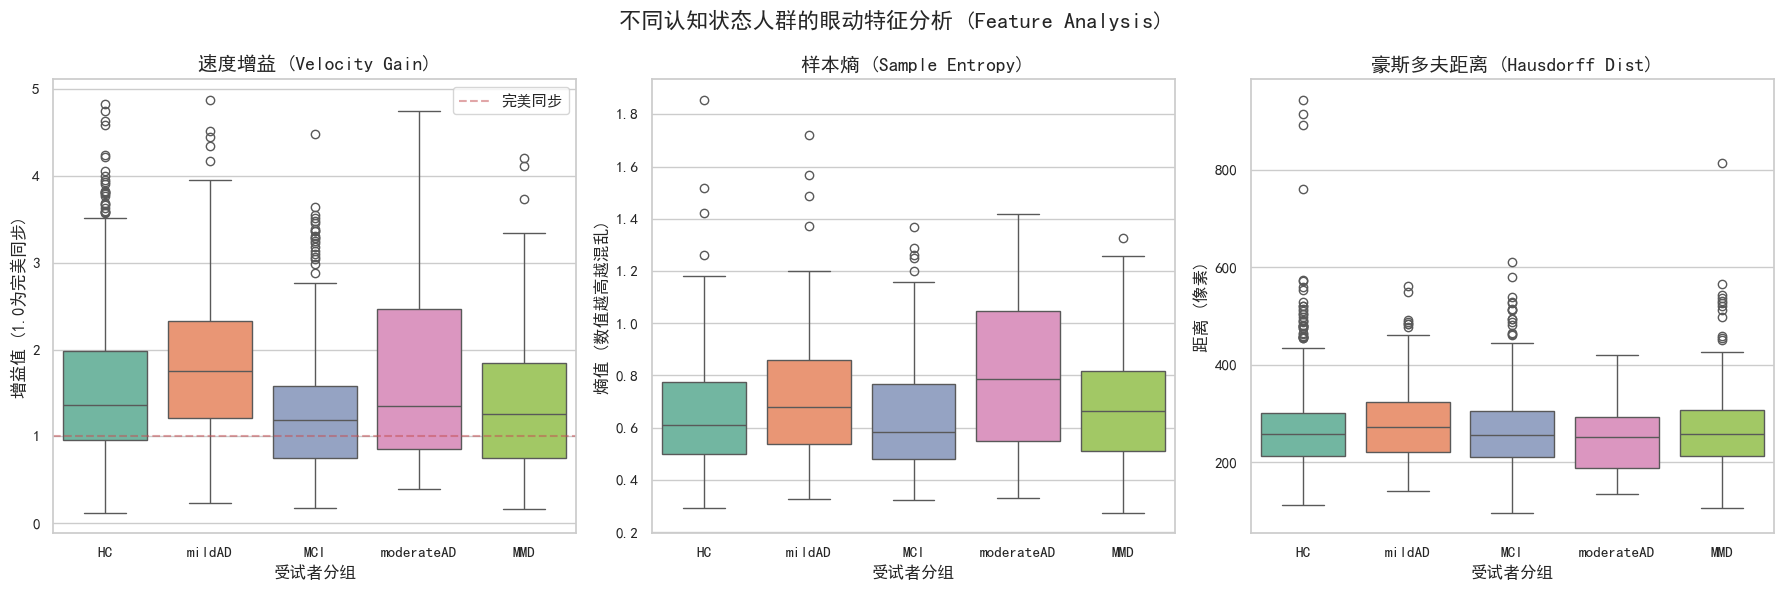


>>> 分析完成，图表已生成。


In [30]:
import pandas as pd
import numpy as np
import os
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.spatial.distance import directed_hausdorff

# ==============================================================================
# 1. 基础配置与中文支持
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# --- 绘图字体设置 (解决中文乱码) ---
# Windows系统通常使用 SimHei (黑体) 或 Microsoft YaHei
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 文件与列名
FILE_INFO = "ParticipantsInfo.xlsx"
DIR_DATA  = "ParticipantsData"
FILE_PP   = "pingpang.csv"
FILE_TN   = "tennis.csv"

# 物理参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# ==============================================================================
# 2. 核心数学工具函数
# ==============================================================================

def sampen(L, m=2, r=0.2):
    """
    计算样本熵 (Sample Entropy)
    L: 数据序列
    m: 模板长度 (通常取2)
    r: 阈值系数 (通常取0.2 * std)
    """
    N = len(L)
    B = 0.0
    A = 0.0

    # 标准化数据
    std_L = np.std(L)
    if std_L == 0: return 0 # 避免除零
    r *= std_L

    # 拆分数据
    x = np.array([L[i:i+m] for i in range(N-m)])
    x_plus = np.array([L[i:i+m+1] for i in range(N-m-1)])

    # 计算 B (相似模板数)
    # 由于Python循环慢，这里用简化的距离计算来加速演示
    # 实际科研中建议使用 nolds 库或编译过的 C 扩展
    # 这里使用简化的向量化计算 (Chebyshev distance)
    for i in range(len(x)):
        dist = np.max(np.abs(x - x[i]), axis=1)
        # 排除自匹配 (dist > 0) 且在阈值内
        B += np.sum((dist <= r) & (dist > 0))

    # 计算 A (m+1长度的相似模板数)
    for i in range(len(x_plus)):
        dist = np.max(np.abs(x_plus - x_plus[i]), axis=1)
        A += np.sum((dist <= r) & (dist > 0))

    if A == 0 or B == 0: return 0
    return -np.log(A / B)

def calculate_expert_features(df_eye, df_ball):
    """
    计算医学级特征：速度增益、样本熵、豪斯多夫距离
    """
    # 1. 插值对齐
    f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
    f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

    ball_x = f_x(df_eye['time'])
    ball_y = f_y(df_eye['time'])

    valid_mask = ~np.isnan(ball_x) & ~np.isnan(df_eye['gaze_x'])
    if np.sum(valid_mask) < 50: return None # 数据太少

    # 提取有效序列
    gx, gy = df_eye.loc[valid_mask, 'gaze_x'].values, df_eye.loc[valid_mask, 'gaze_y'].values
    bx, by = ball_x[valid_mask], ball_y[valid_mask]

    # --- 特征 A: 速度增益 (Velocity Gain) ---
    # 计算速度 (差分 / 时间间隔)
    dt = 1.0 / EYE_FPS
    g_vel = np.sqrt(np.diff(gx)**2 + np.diff(gy)**2) / dt
    b_vel = np.sqrt(np.diff(bx)**2 + np.diff(by)**2) / dt

    # 平滑处理 (简单的移动平均，减少噪音干扰)
    window = 5
    g_vel_smooth = np.convolve(g_vel, np.ones(window)/window, mode='valid')
    b_vel_smooth = np.convolve(b_vel, np.ones(window)/window, mode='valid')

    mean_g_vel = np.mean(g_vel_smooth)
    mean_b_vel = np.mean(b_vel_smooth)

    velocity_gain = mean_g_vel / mean_b_vel if mean_b_vel > 0 else np.nan

    # --- 特征 B: 误差信号的样本熵 (Error Sample Entropy) ---
    # 计算欧氏距离误差序列
    error_seq = np.sqrt((gx - bx)**2 + (gy - by)**2)
    # 对误差序列计算熵 (衡量误差的混乱程度，越乱说明神经控制越差)
    # 为了速度，截取中间段或下采样
    samp_en = sampen(error_seq[::2], m=2, r=0.2)

    # --- 特征 C: 豪斯多夫距离 (Hausdorff Distance) ---
    # 衡量两组轨迹在空间上的最大不匹配度
    u = np.column_stack([gx, gy])
    v = np.column_stack([bx, by])
    # directed_hausdorff 返回 (距离, idx1, idx2)，我们只取距离
    h_dist = max(directed_hausdorff(u, v)[0], directed_hausdorff(v, u)[0])

    return {
        'Velocity_Gain': velocity_gain,   # 速度增益
        'Sample_Entropy': samp_en,        # 样本熵
        'Hausdorff_Dist': h_dist          # 豪斯多夫距离
    }

# ==============================================================================
# 3. 数据加载辅助函数
# ==============================================================================

def load_ball_library():
    # 加载球轨迹 (同前)
    path_pp = os.path.join(BASE_DIR, FILE_PP)
    path_tn = os.path.join(BASE_DIR, FILE_TN)
    if not os.path.exists(path_pp): return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))

    sx, sy = SCREEN_W/VIDEO_W, SCREEN_H/VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * sx - (SCREEN_W/2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * sy - (SCREEN_H/2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    return {k: v for k, v in df_all.dropna(subset=['ball_x']).groupby('video_name')}

def process_single_row(eye_data_str):
    if not isinstance(eye_data_str, str): return None
    parsed = []
    for frame in eye_data_str.split(';'):
        if not frame.strip() or "Screen.x" in frame: continue
        vals = [float(v) if v != 'NaN' else np.nan for v in frame.strip().split()]
        if len(vals) >= 2: parsed.append(vals[:2])
    df = pd.DataFrame(parsed, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / EYE_FPS)
    return df

def get_info_map():
    path = os.path.join(BASE_DIR, FILE_INFO)
    if not os.path.exists(path): return {}
    try:
        df = pd.read_excel(path, dtype={"No.": str})
        mapping = {}
        for _, row in df.iterrows():
            f = str(row.get("PicoFile")).strip()
            if not f.lower().endswith('.csv'): f += ".csv"
            mapping[f] = {'Label': row.get("Label", 'Unknown'), 'No': row.get("No.", 'Unknown')}
        return mapping
    except: return {}

# ==============================================================================
# 4. 主程序
# ==============================================================================

def main():
    print(">>> 正在初始化高级算法模块...")
    ball_lib = load_ball_library()
    info_map = get_info_map()
    all_files = glob.glob(os.path.join(BASE_DIR, DIR_DATA, "*.csv"))

    if not ball_lib or not all_files:
        print("错误：数据文件缺失")
        return

    print(f">>> 开始对 {len(all_files)} 个受试者文件进行深度特征提取...")
    results = []

    for fpath in all_files:
        fname = os.path.basename(fpath)

        # 智能标签识别
        if fname in info_map:
            no, label = info_map[fname]['No'], info_map[fname]['Label']
        else:
            name_upper = os.path.splitext(fname)[0].upper()
            label = 'Unknown'
            if 'HC' in name_upper: label = 'HC'
            elif 'AD' in name_upper: label = 'AD'
            elif 'MCI' in name_upper: label = 'MCI'
            elif 'MMD' in name_upper: label = 'MMD'
            no = name_upper.split('_')[0]

        try:
            df_part = pd.read_csv(fpath)
            if "videoName" not in df_part.columns or "EyeData" not in df_part.columns: continue

            for _, row in df_part.iterrows():
                vid = str(row["videoName"]).strip()
                if vid in ball_lib:
                    df_eye = process_single_row(row["EyeData"])
                    if df_eye is not None:
                        # === 执行高级算法 ===
                        feats = calculate_expert_features(df_eye, ball_lib[vid])

                        if feats:
                            # 过滤极端异常值
                            if feats['Velocity_Gain'] < 5.0 and feats['Sample_Entropy'] < 10:
                                res_item = {
                                    'Label': label, 'No': no, 'File': fname,
                                    '速度增益': feats['Velocity_Gain'],
                                    '样本熵(混乱度)': feats['Sample_Entropy'],
                                    '豪斯多夫距离': feats['Hausdorff_Dist']
                                }
                                results.append(res_item)
        except: pass

    # --- 绘图与分析 ---
    df = pd.DataFrame(results)
    if df.empty: print("无有效数据"); return

    # 剔除Unknown
    df_plot = df[df['Label'] != 'Unknown'].copy()

    # 打印中文统计表
    print("\n" + "="*50)
    print("各组病理特征均值对比表")
    print("="*50)
    summary = df_plot.groupby('Label')[['速度增益', '样本熵(混乱度)', '豪斯多夫距离']].mean()
    print(summary)

    # --- 高级可视化 (Seaborn Boxplot) ---
    # 设置风格
    sns.set(style="whitegrid", font='SimHei') # 确保Seaborn也使用中文
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('不同认知状态人群的眼动特征分析 (Feature Analysis)', fontsize=16)

    # 1. 速度增益图
    sns.boxplot(x='Label', y='速度增益', data=df_plot, ax=axes[0], palette="Set2")
    axes[0].set_title('速度增益 (Velocity Gain)', fontsize=14)
    axes[0].set_ylabel('增益值 (1.0为完美同步)', fontsize=12)
    axes[0].set_xlabel('受试者分组', fontsize=12)
    # 添加参考线
    axes[0].axhline(1.0, color='r', linestyle='--', alpha=0.5, label='完美同步')
    axes[0].legend()

    # 2. 样本熵图
    sns.boxplot(x='Label', y='样本熵(混乱度)', data=df_plot, ax=axes[1], palette="Set2")
    axes[1].set_title('样本熵 (Sample Entropy)', fontsize=14)
    axes[1].set_ylabel('熵值 (数值越高越混乱)', fontsize=12)
    axes[1].set_xlabel('受试者分组', fontsize=12)

    # 3. 豪斯多夫距离图
    sns.boxplot(x='Label', y='豪斯多夫距离', data=df_plot, ax=axes[2], palette="Set2")
    axes[2].set_title('豪斯多夫距离 (Hausdorff Dist)', fontsize=14)
    axes[2].set_ylabel('距离 (像素)', fontsize=12)
    axes[2].set_xlabel('受试者分组', fontsize=12)

    plt.tight_layout()
    plt.show()
    print("\n>>> 分析完成，图表已生成。")

if __name__ == "__main__":
    main()


开始处理 73 个文件，提取高级特征...

各组特征均值对比 (Feature Comparison)
            Time_Lag_ms  Velocity_Corr  Focus_Rate
Label                                             
HC          -622.093863       0.131665    0.273440
MCI         -585.507246       0.107843    0.283617
MMD         -652.222222       0.073741    0.301312
mildAD      -597.810219       0.178937    0.253877
moderateAD  -574.666667       0.201263    0.328616

结果已保存至 Advanced_Features_Analysis.xlsx


C:\Users\81026\AppData\Local\Temp\ipykernel_23804\478455882.py:237: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Time_Lag_ms', data=df_plot, palette="Set3")
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\478455882.py:243: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Velocity_Corr', data=df_plot, palette="Set3")
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\478455882.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Focus_Rate', data=df_plot, palette="Set3")


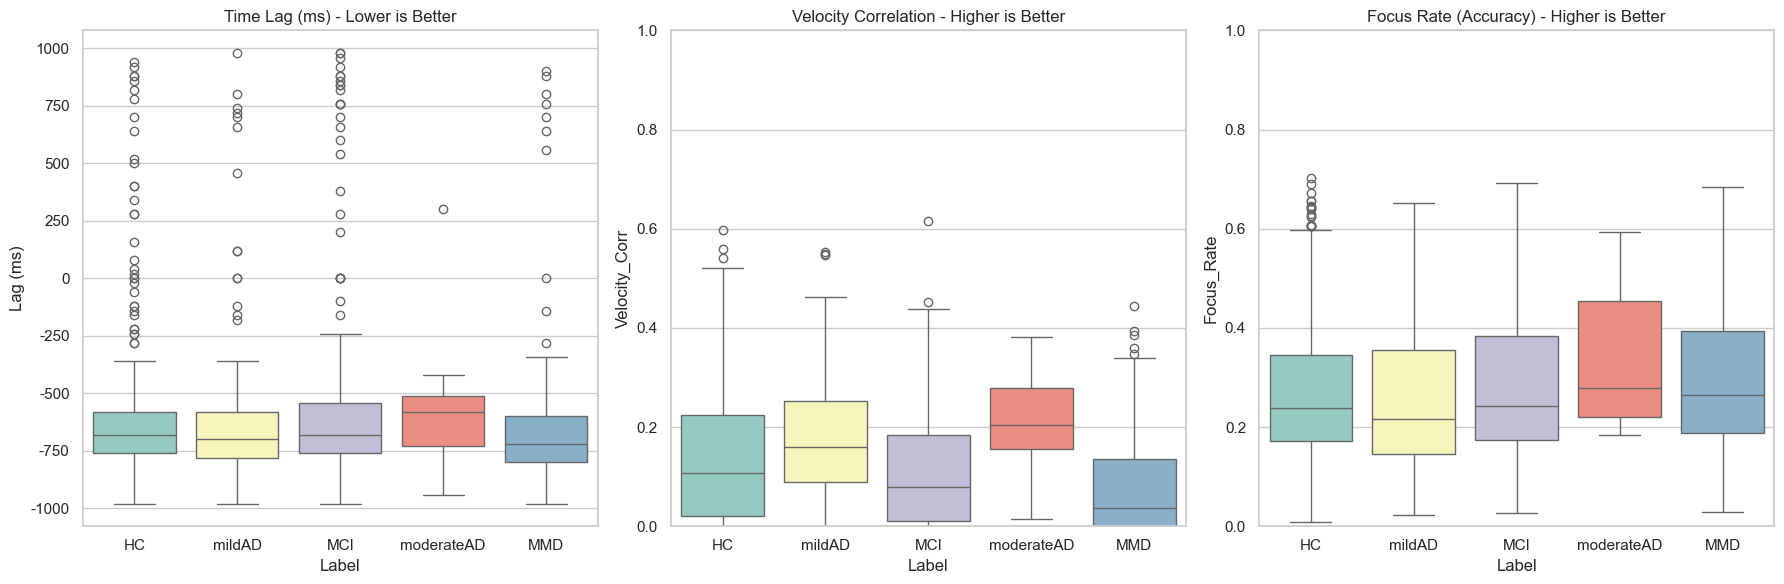

In [3]:
import pandas as pd
import numpy as np
import os
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import correlate

# ==============================================================================
# 1. 配置区域
# ==============================================================================

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

# 文件设定
FILE_INFO             = "ParticipantsInfo.xlsx"
DIR_PARTICIPANTS_DATA = "ParticipantsData"
FILE_PINGPANG         = "pingpang.csv"
FILE_TENNIS           = "tennis.csv"

# 参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# 特征计算参数
LAG_SEARCH_RANGE   = 20   # 搜索前后 20帧 (约 +/- 400ms) 的滞后
FOCUS_THRESHOLD_PX = 150  # 误差小于 150px 算作“有效注视”

# ==============================================================================
# 2. 核心工具函数 (加载与基础处理)
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PINGPANG)
    path_tn = os.path.join(BASE_DIR, FILE_TENNIS)
    if not os.path.exists(path_pp) or not os.path.exists(path_tn): return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
    df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))

    scale_x = SCREEN_W / VIDEO_W
    scale_y = SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * scale_x - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * scale_y - (SCREEN_H / 2)
    df_all['time'] = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    df_clean = df_all.dropna(subset=['ball_x', 'ball_y'])
    return {k: v for k, v in df_clean.groupby('video_name')}

def process_single_row(eye_data_str, eye_fps):
    if not isinstance(eye_data_str, str): return None
    frames = eye_data_str.split(';')
    parsed_data = []
    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue
        vals = frame.strip().split()
        row = [float(v) if v != 'NaN' else np.nan for v in vals]
        if len(row) >= 2: parsed_data.append(row[:2])

    df = pd.DataFrame(parsed_data, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / eye_fps)
    return df

def get_label_info_map():
    info_path = os.path.join(BASE_DIR, FILE_INFO)
    if not os.path.exists(info_path): return {}
    try:
        df_info = pd.read_excel(info_path, dtype={"No.": str})
        info_map = {}
        for _, row in df_info.iterrows():
            fname = row.get("PicoFile")
            if pd.isna(fname): continue
            clean_fname = str(fname).strip()
            if not clean_fname.lower().endswith('.csv'): clean_fname += ".csv"
            info_map[clean_fname] = {
                'Label': row.get("Label", 'Unknown'),
                'No': row.get("No.", 'Unknown')
            }
        return info_map
    except Exception: return {}

# ==============================================================================
# 3. 高级特征提取算法 (核心修改部分)
# ==============================================================================

def calculate_advanced_features(df_eye, df_ball):
    """
    计算三个高级特征：
    1. Time_Lag (ms): 滞后时间
    2. Velocity_Corr: 速度相关性
    3. Focus_Rate: 有效注视比率
    """
    # --- 1. 数据对齐与插值 ---
    # 创建插值函数
    f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
    f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

    # 获取每一帧的球位置
    ball_x = f_x(df_eye['time'])
    ball_y = f_y(df_eye['time'])

    # 剔除无效数据 (NaN) 用于计算
    valid_mask = ~np.isnan(ball_x) & ~np.isnan(df_eye['gaze_x'])
    if np.sum(valid_mask) < 50: # 如果有效数据太少，无法计算
        return np.nan, np.nan, np.nan

    g_x, g_y = df_eye.loc[valid_mask, 'gaze_x'].values, df_eye.loc[valid_mask, 'gaze_y'].values
    b_x, b_y = ball_x[valid_mask], ball_y[valid_mask]

    # --- 特征 A: 滞后时间 (Time Lag) ---
    # 使用互相关 (Cross-Correlation) 计算 X 轴方向的最佳偏移
    # 为什么只用X轴？因为乒乓球/网球主要是左右移动，X轴信号最强
    lags = correlate(g_x - np.mean(g_x), b_x - np.mean(b_x), mode='full')
    lag_index = np.argmax(lags)
    # 将索引转换为偏移帧数
    shift_frames = lag_index - (len(g_x) - 1)
    # 转换为毫秒 (负数代表滞后，正数代表超前，通常关注绝对值或负值)
    # 修正逻辑：我们关心的是“眼动比球晚了多少”，通常是正数表示滞后
    time_lag_ms = -shift_frames * (1000 / EYE_FPS)

    # --- 特征 B: 速度相关性 (Velocity Correlation) ---
    # 计算速度 (差分)
    g_vel_x = np.diff(g_x)
    g_vel_y = np.diff(g_y)
    b_vel_x = np.diff(b_x)
    b_vel_y = np.diff(b_y)

    # 合成速度大小
    g_speed = np.sqrt(g_vel_x**2 + g_vel_y**2)
    b_speed = np.sqrt(b_vel_x**2 + b_vel_y**2)

    # 计算相关系数
    if len(g_speed) > 10:
        vel_corr = np.corrcoef(g_speed, b_speed)[0, 1]
    else:
        vel_corr = np.nan

    # --- 特征 C: 有效注视率 (Focus Rate) ---
    dists = np.sqrt((g_x - b_x)**2 + (g_y - b_y)**2)
    # 统计有多少比例的点在阈值范围内
    focus_rate = np.sum(dists < FOCUS_THRESHOLD_PX) / len(dists)

    return time_lag_ms, vel_corr, focus_rate

# ==============================================================================
# 4. 主程序
# ==============================================================================

def main():
    ball_lib = load_ball_library()
    if not ball_lib: print("加载球轨迹失败"); return

    info_map = get_label_info_map()
    data_dir = os.path.join(BASE_DIR, DIR_PARTICIPANTS_DATA)
    all_files = glob.glob(os.path.join(data_dir, "*.csv"))

    print(f"开始处理 {len(all_files)} 个文件，提取高级特征...")

    results = []

    for file_path in all_files:
        file_name = os.path.basename(file_path)

        # 标签识别
        if file_name in info_map:
            no_id, label = info_map[file_name]['No'], info_map[file_name]['Label']
        else:
            name_part = os.path.splitext(file_name)[0].upper()
            label = 'Unknown'
            if 'HC' in name_part: label = 'HC'
            elif 'AD' in name_part: label = 'AD'
            elif 'MCI' in name_part: label = 'MCI'
            elif 'MMD' in name_part: label = 'MMD'
            no_id = name_part.split('_')[0]

        try:
            df_part = pd.read_csv(file_path)
            if "videoName" not in df_part.columns or "EyeData" not in df_part.columns: continue

            for _, data_row in df_part.iterrows():
                video_name = str(data_row["videoName"]).strip()
                eye_str = data_row["EyeData"]

                if video_name in ball_lib:
                    df_eye = process_single_row(eye_str, EYE_FPS)
                    if df_eye is not None and len(df_eye) > 50:
                        df_ball = ball_lib[video_name]

                        # === 调用新的特征计算 ===
                        lag, v_corr, focus = calculate_advanced_features(df_eye, df_ball)

                        # 简单的异常值过滤 (例如 Lag 不可能超过 1000ms)
                        if abs(lag) < 1000:
                            results.append({
                                'Label': label,
                                'No': no_id,
                                'File': file_name,
                                'Time_Lag_ms': lag,       # 越小越好 (接近0)
                                'Velocity_Corr': v_corr,  # 越大越好 (接近1)
                                'Focus_Rate': focus       # 越大越好 (接近1)
                            })
                            # print(f"[{label}] Lag:{lag:.1f}ms | Corr:{v_corr:.2f} | Focus:{focus:.2f}")

        except Exception: pass

    # --- 结果分析与绘图 ---
    df_res = pd.DataFrame(results)
    if df_res.empty: print("无有效数据"); return

    # 剔除 Unknown 以便画图清晰
    df_plot = df_res[df_res['Label'] != 'Unknown'].copy()

    print("\n" + "="*60)
    print("各组特征均值对比 (Feature Comparison)")
    print("="*60)
    # 按标签分组计算均值
    summary = df_plot.groupby('Label')[['Time_Lag_ms', 'Velocity_Corr', 'Focus_Rate']].mean()
    print(summary)

    # 保存结果
    df_res.to_excel(os.path.join(BASE_DIR, "Advanced_Features_Analysis.xlsx"), index=False)
    print(f"\n结果已保存至 Advanced_Features_Analysis.xlsx")

    # === 画图：箱线图 (Boxplot) ===
    # 这张图最能体现“显著性”
    plt.figure(figsize=(18, 6))

    # 设置绘图风格
    sns.set(style="whitegrid")

    # 子图1: 滞后时间
    plt.subplot(1, 3, 1)
    sns.boxplot(x='Label', y='Time_Lag_ms', data=df_plot, palette="Set3")
    plt.title('Time Lag (ms) - Lower is Better')
    plt.ylabel('Lag (ms)')

    # 子图2: 速度相关性
    plt.subplot(1, 3, 2)
    sns.boxplot(x='Label', y='Velocity_Corr', data=df_plot, palette="Set3")
    plt.title('Velocity Correlation - Higher is Better')
    plt.ylim(0, 1) # 相关性通常在 0-1 之间

    # 子图3: 有效注视率
    plt.subplot(1, 3, 3)
    sns.boxplot(x='Label', y='Focus_Rate', data=df_plot, palette="Set3")
    plt.title('Focus Rate (Accuracy) - Higher is Better')
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


>>> 使用中文字体: Microsoft YaHei  (C:\Windows\Fonts\msyh.ttc)
>>> [Phase 1] 初始化数据...
>>> [Phase 2] 开始挖掘 73 个文件的注视分布特征...

>>> [Phase 3] 生成美观的对比图表...


C:\Users\81026\AppData\Local\Temp\ipykernel_23804\2833142580.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\2833142580.py:309: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\2833142580.py:321: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\2833142580.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

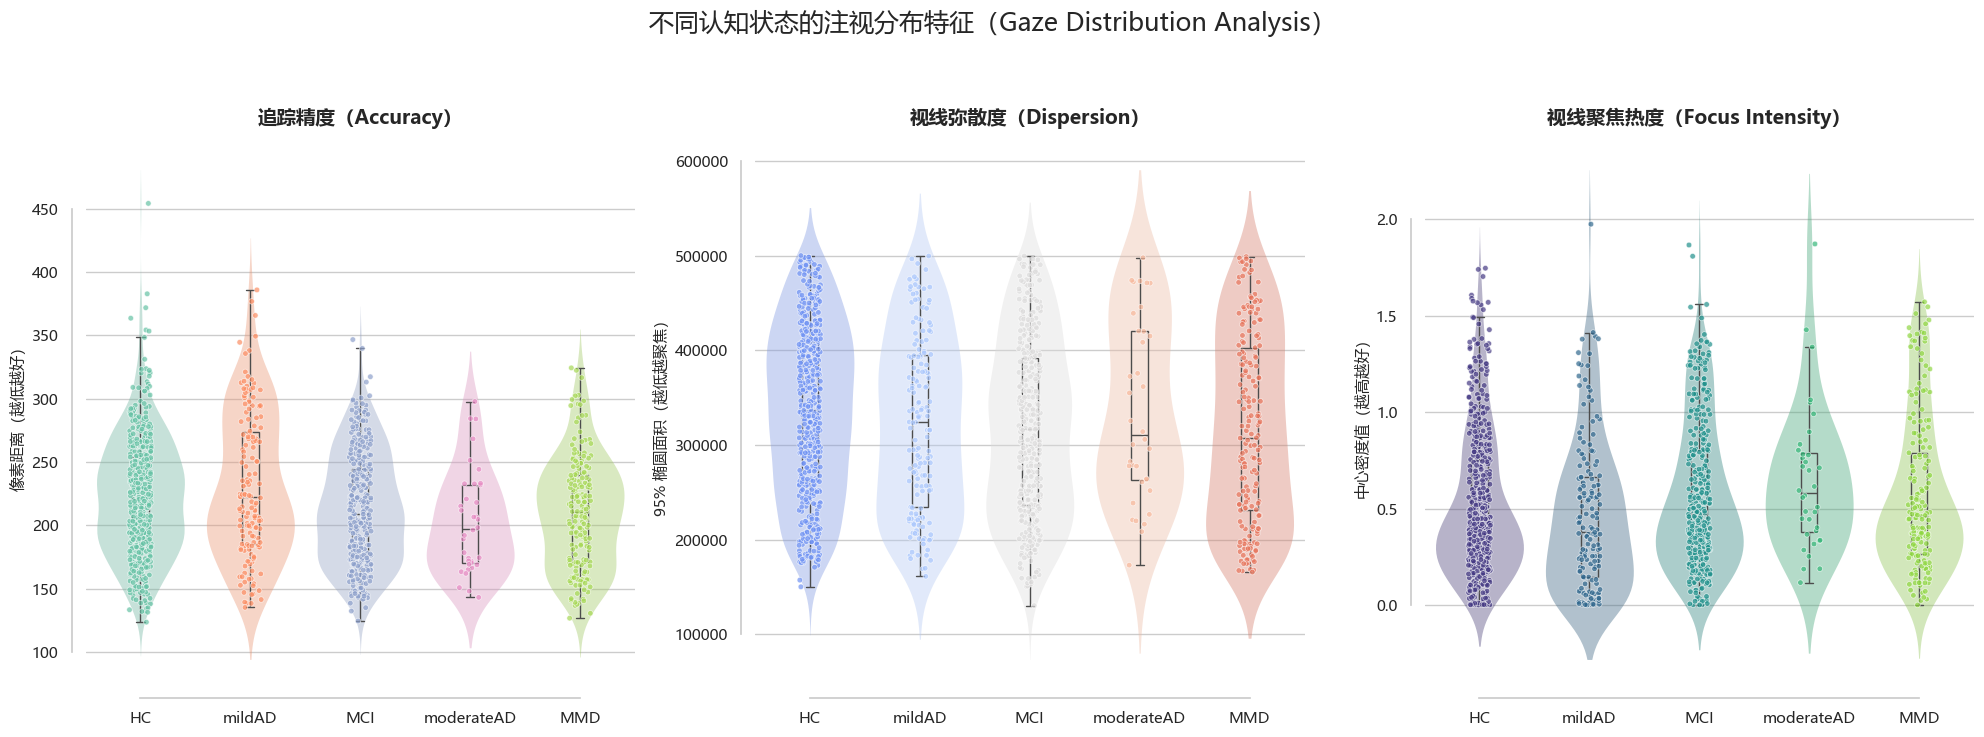


分布特征统计均值表
            平均误差(Mean Error)     弥散面积(BCEA)  聚焦密度(KDE Density)
Label                                                         
HC                222.773365  335871.302885           0.517842
MCI               213.251870  316804.406191           0.563788
MMD               210.201907  316554.850975           0.570609
mildAD            231.338208  322162.368787           0.461892
moderateAD        202.807357  335365.351140           0.648348


In [5]:
import pandas as pd
import numpy as np
import os
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

# ==============================================================================
# 1. 基础配置与中文支持（修复：方块字 -> 正常中文）
# ==============================================================================

from matplotlib import font_manager

BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"

def setup_cn_font():
    """
    强制注册并使用中文字体（Windows：优先微软雅黑，其次黑体/宋体）
    彻底解决图中中文显示为“方块”的问题。
    """
    font_files = [
        r"C:\Windows\Fonts\msyh.ttc",     # 微软雅黑
        r"C:\Windows\Fonts\msyh.ttf",
        r"C:\Windows\Fonts\simhei.ttf",   # 黑体
        r"C:\Windows\Fonts\simsun.ttc",   # 宋体
    ]

    for fp in font_files:
        if os.path.exists(fp):
            font_manager.fontManager.addfont(fp)
            font_name = font_manager.FontProperties(fname=fp).get_name()

            # Matplotlib 全局字体设置
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [font_name]
            plt.rcParams["axes.unicode_minus"] = False

            # 导出矢量图时也能正常嵌入字体（可选但推荐）
            plt.rcParams["pdf.fonttype"] = 42
            plt.rcParams["ps.fonttype"] = 42

            print(f">>> 使用中文字体: {font_name}  ({fp})")
            return font_name

    # 如果字体文件不存在，尝试按名称匹配（次稳定）
    fallback_names = ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in fallback_names:
        if name in available:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [name]
            plt.rcParams["axes.unicode_minus"] = False
            print(f">>> 使用中文字体(按名称匹配): {name}")
            return name

    print("!!! 警告：未找到可用中文字体，图中可能仍显示方块。")
    return None

CN_FONT_NAME = setup_cn_font()

# seaborn 风格（透明背景 + 同步字体）
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": (0, 0, 0, 0),
        "font.sans-serif": plt.rcParams.get("font.sans-serif", []),
        "axes.unicode_minus": False,
    },
)

# 文件与列名
FILE_INFO = "ParticipantsInfo.xlsx"
DIR_DATA  = "ParticipantsData"
FILE_PP   = "pingpang.csv"
FILE_TN   = "tennis.csv"

# 物理参数
SCREEN_W, SCREEN_H = 1280, 720
VIDEO_W, VIDEO_H   = 1920, 1080
EYE_FPS            = 50
VIDEO_PLAYBACK_FPS = 30

# ==============================================================================
# 2. 核心数学工具：分布特征提取
# ==============================================================================

def calculate_bcea(x_error, y_error, probability=0.95):
    """
    计算双变量轮廓椭圆面积 (BCEA) - 衡量注视点的离散面积
    """
    if len(x_error) < 10:
        return np.nan

    cov = np.cov(x_error, y_error)
    vals, _ = np.linalg.eigh(cov)

    # 数值稳定：协方差特征值可能出现极小负数，裁剪为 0
    vals = np.clip(vals, 0, None)

    # P=0.95 -> k=5.991（等价形式：k = -2 ln(1-P)）
    k = -2 * np.log(1 - probability)

    area = np.pi * np.sqrt(vals[0] * vals[1]) * k
    return area

def calculate_kde_peak(x_error, y_error):
    """
    计算核密度估计 (KDE) 的中心点密度 - 衡量注视的聚焦程度
    """
    if len(x_error) < 10:
        return np.nan
    try:
        values = np.vstack([x_error, y_error])
        kernel = gaussian_kde(values)
        density_at_center = kernel(np.array([[0], [0]]))
        return float(density_at_center[0])
    except Exception:
        return np.nan

def calculate_distribution_features(df_eye, df_ball):
    """
    提取空间分布特征
    """
    # 1) 插值对齐
    f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
    f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)

    bx = f_x(df_eye['time'])
    by = f_y(df_eye['time'])

    # 2) 相对误差序列 (Gaze - Ball)，以球为原点
    error_x = df_eye['gaze_x'] - bx
    error_y = df_eye['gaze_y'] - by

    # 剔除 NaN
    mask = ~np.isnan(error_x) & ~np.isnan(error_y)
    ex, ey = error_x[mask].to_numpy(), error_y[mask].to_numpy()

    if len(ex) < 50:
        return None

    # A: 欧氏距离均值
    mean_dist = np.mean(np.sqrt(ex**2 + ey**2))

    # B: BCEA 95% 椭圆面积
    bcea_area = calculate_bcea(ex, ey, probability=0.95)

    # C: KDE 中心密度（越大越聚焦）
    kde_peak = calculate_kde_peak(ex, ey)

    return {
        'Mean_Error': float(mean_dist),
        'BCEA_Area': float(bcea_area) if np.isfinite(bcea_area) else np.nan,
        'KDE_Density': float(kde_peak) * 100000 if np.isfinite(kde_peak) else np.nan
    }

# ==============================================================================
# 3. 数据加载与处理
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PP)
    path_tn = os.path.join(BASE_DIR, FILE_TN)
    if not os.path.exists(path_pp) or not os.path.exists(path_tn):
        return {}

    df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)

    df_all['pos_tuple'] = df_all['position'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan)
    )

    sx, sy = SCREEN_W / VIDEO_W, SCREEN_H / VIDEO_H
    df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * sx - (SCREEN_W / 2)
    df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * sy - (SCREEN_H / 2)
    df_all['time']   = df_all['frame_number'] / VIDEO_PLAYBACK_FPS

    # 只保留有效球坐标
    df_all = df_all.dropna(subset=['ball_x', 'ball_y', 'time', 'video_name'])
    return {k: v for k, v in df_all.groupby('video_name')}

def process_single_row(eye_data_str):
    if not isinstance(eye_data_str, str):
        return None
    parsed = []
    for frame in eye_data_str.split(';'):
        if not frame.strip() or "Screen.x" in frame:
            continue
        vals = [float(v) if v != 'NaN' else np.nan for v in frame.strip().split()]
        if len(vals) >= 2:
            parsed.append(vals[:2])

    if not parsed:
        return None

    df = pd.DataFrame(parsed, columns=['gaze_x', 'gaze_y'])
    df['time'] = df.index * (1.0 / EYE_FPS)
    return df

def get_info_map():
    path = os.path.join(BASE_DIR, FILE_INFO)
    try:
        df = pd.read_excel(path, dtype={"No.": str})
        mapping = {}
        for _, row in df.iterrows():
            f = str(row.get("PicoFile", "")).strip()
            if not f:
                continue
            if not f.lower().endswith('.csv'):
                f += ".csv"
            mapping[f] = {'Label': row.get("Label", 'Unknown'), 'No': row.get("No.", 'Unknown')}
        return mapping
    except Exception:
        return {}

# ==============================================================================
# 4. 主程序
# ==============================================================================

def main():
    print(">>> [Phase 1] 初始化数据...")
    ball_lib = load_ball_library()
    info_map = get_info_map()
    all_files = glob.glob(os.path.join(BASE_DIR, DIR_DATA, "*.csv"))

    if not ball_lib or not all_files:
        print("错误：数据缺失（ball_lib 或 ParticipantsData/*.csv 不存在）")
        return

    print(f">>> [Phase 2] 开始挖掘 {len(all_files)} 个文件的注视分布特征...")
    results = []

    for fpath in all_files:
        fname = os.path.basename(fpath)

        # 标签逻辑
        if fname in info_map:
            no, label = info_map[fname]['No'], info_map[fname]['Label']
        else:
            name_upper = os.path.splitext(fname)[0].upper()
            label = 'Unknown'
            if 'HC' in name_upper:
                label = 'HC'
            elif 'MILDAD' in name_upper:
                label = 'mildAD'
            elif 'MODERATEAD' in name_upper:
                label = 'moderateAD'
            elif 'AD' in name_upper:
                label = 'AD'
            elif 'MCI' in name_upper:
                label = 'MCI'
            elif 'MMD' in name_upper:
                label = 'MMD'
            no = name_upper.split('_')[0]

        try:
            df_part = pd.read_csv(fpath)
            if "videoName" not in df_part.columns or "EyeData" not in df_part.columns:
                continue

            for _, row in df_part.iterrows():
                vid = str(row["videoName"]).strip()
                if vid not in ball_lib:
                    continue

                df_eye = process_single_row(row["EyeData"])
                if df_eye is None:
                    continue

                feats = calculate_distribution_features(df_eye, ball_lib[vid])
                if not feats:
                    continue

                # 简单清洗异常值
                if np.isfinite(feats['BCEA_Area']) and feats['BCEA_Area'] < 500000:
                    results.append({
                        'Label': label,
                        'No': no,
                        'File': fname,
                        '平均误差(Mean Error)': feats['Mean_Error'],
                        '弥散面积(BCEA)': feats['BCEA_Area'],
                        '聚焦密度(KDE Density)': feats['KDE_Density']
                    })
        except Exception:
            # 你原本是 pass，这里保持同样行为
            pass

    df = pd.DataFrame(results)
    if df.empty:
        print("无有效数据")
        return

    # 剔除 Unknown
    df_plot = df[df['Label'] != 'Unknown'].copy()
    if df_plot.empty:
        print("剔除 Unknown 后无有效数据")
        return

    print("\n>>> [Phase 3] 生成美观的对比图表...")

    # Raincloud 风格：小提琴 + 散点 + 箱线
    def plot_feature(ax, data, x, y, title, ylabel, color_palette="viridis"):
        # 1) 小提琴图
        # seaborn 不同版本参数可能有差异，这里做兼容
        try:
            sns.violinplot(
                x=x, y=y, data=data, ax=ax,
                palette=color_palette, inner=None, linewidth=0, alpha=0.4, scale="width"
            )
        except TypeError:
            # 新版 seaborn 用 density_norm 替代 scale
            sns.violinplot(
                x=x, y=y, data=data, ax=ax,
                palette=color_palette, inner=None, linewidth=0, alpha=0.4, density_norm="width"
            )

        # 2) 抖动散点图
        sns.stripplot(
            x=x, y=y, data=data, ax=ax,
            palette=color_palette, size=4, alpha=0.7, jitter=True,
            edgecolor="white", linewidth=0.5
        )

        # 3) 箱线图叠加
        sns.boxplot(
            x=x, y=y, data=data, ax=ax,
            width=0.15, boxprops={'zorder': 2, 'facecolor': 'none'},
            showfliers=False
        )

        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel("")
        sns.despine(ax=ax, offset=10, trim=True)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle('不同认知状态的注视分布特征（Gaze Distribution Analysis）', fontsize=18, y=1.05)

    # 图1：平均误差
    plot_feature(
        axes[0], df_plot, 'Label', '平均误差(Mean Error)',
        '追踪精度（Accuracy）', '像素距离（越低越好）', "Set2"
    )

    # 图2：BCEA 面积
    plot_feature(
        axes[1], df_plot, 'Label', '弥散面积(BCEA)',
        '视线弥散度（Dispersion）', '95% 椭圆面积（越低越聚焦）', "coolwarm"
    )

    # 图3：KDE 密度
    plot_feature(
        axes[2], df_plot, 'Label', '聚焦密度(KDE Density)',
        '视线聚焦热度（Focus Intensity）', '中心密度值（越高越好）', "viridis"
    )

    plt.tight_layout()
    plt.show()

    # 打印统计表
    print("\n" + "=" * 60)
    print("分布特征统计均值表")
    print("=" * 60)
    print(df_plot.groupby('Label')[['平均误差(Mean Error)', '弥散面积(BCEA)', '聚焦密度(KDE Density)']].mean())

if __name__ == "__main__":
    main()


>>> 使用中文字体: Microsoft YaHei  (C:\Windows\Fonts\msyh.ttc)
>>> 正在启动多维特征提取 (修复版)...
>>> 扫描到 73 个文件


C:\Users\81026\AppData\Local\Temp\ipykernel_23804\1697511295.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  signal = df_eye['gaze_x'].fillna(method='ffill').fillna(method='bfill')
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\1697511295.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  signal = df_eye['gaze_x'].fillna(method='ffill').fillna(method='bfill')
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\1697511295.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  signal = df_eye['gaze_x'].fillna(method='ffill').fillna(method='bfill')
C:\Users\81026\AppData\Local\Temp\ipykernel_23804\1697511295.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ff


>>> 成功提取 3504 条有效记录。正在绘图...

特征均值统计:
            瞳孔直径(Pupil)  扫视占比(Sac Ratio)  低频震荡(Low Freq)
Label                                                   
HC             3.913754         0.321092             NaN
MCI            3.573462         0.264415             NaN
MMD            3.819226         0.304501             NaN
mildAD         3.496582         0.418281             NaN
moderateAD     2.822084         0.425047             NaN


C:\Users\81026\AppData\Local\Temp\ipykernel_23804\1697511295.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Label', y='扫视占比(Sac Ratio)', data=df_plot, ax=axes[1], palette="Oranges", inner='quartile')


警告: 低频震荡数据为空，第三部分未显示


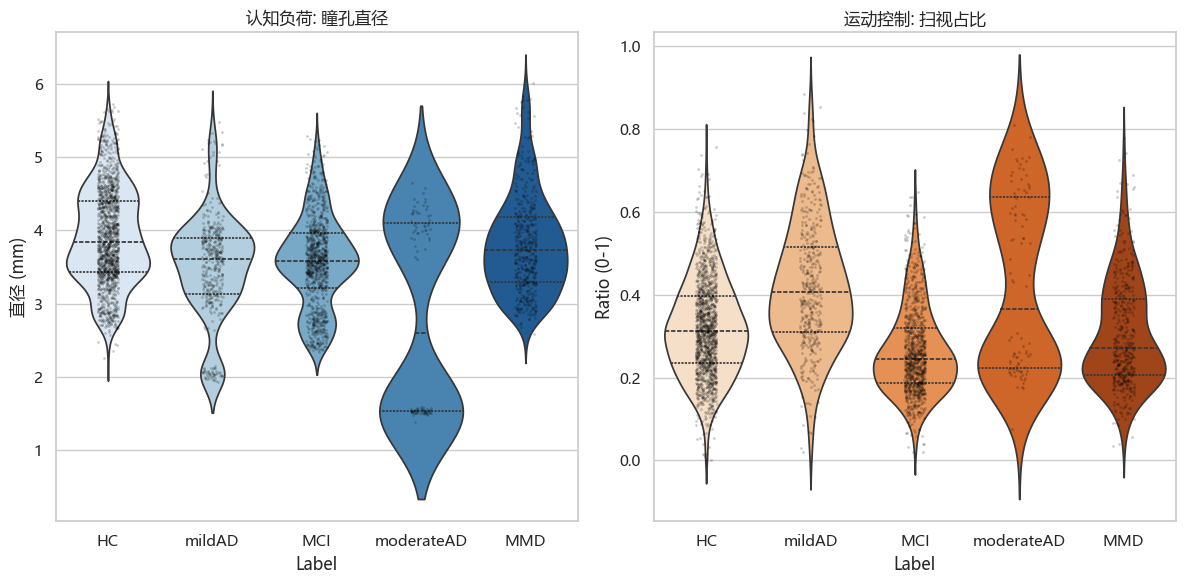


>>> 分析完成！


In [9]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from matplotlib import font_manager

# ==============================================================================
# 1. 配置区域
# ==============================================================================
BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"
FILE_INFO = "ParticipantsInfo.xlsx"
DIR_DATA  = "ParticipantsData"
EYE_FPS = 50

# 设置中文字体 (兼容 Windows/Mac)
def setup_cn_font():
    """
    强制注册并使用中文字体（Windows：优先微软雅黑，其次黑体/宋体）
    彻底解决图中中文显示为“方块”的问题。
    """
    font_files = [
        r"C:\Windows\Fonts\msyh.ttc",     # 微软雅黑
        r"C:\Windows\Fonts\msyh.ttf",
        r"C:\Windows\Fonts\simhei.ttf",   # 黑体
        r"C:\Windows\Fonts\simsun.ttc",   # 宋体
    ]

    for fp in font_files:
        if os.path.exists(fp):
            font_manager.fontManager.addfont(fp)
            font_name = font_manager.FontProperties(fname=fp).get_name()

            # Matplotlib 全局字体设置
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [font_name]
            plt.rcParams["axes.unicode_minus"] = False

            # 导出矢量图时也能正常嵌入字体（可选但推荐）
            plt.rcParams["pdf.fonttype"] = 42
            plt.rcParams["ps.fonttype"] = 42

            print(f">>> 使用中文字体: {font_name}  ({fp})")
            return font_name

    # 如果字体文件不存在，尝试按名称匹配（次稳定）
    fallback_names = ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in fallback_names:
        if name in available:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [name]
            plt.rcParams["axes.unicode_minus"] = False
            print(f">>> 使用中文字体(按名称匹配): {name}")
            return name

    print("!!! 警告：未找到可用中文字体，图中可能仍显示方块。")
    return None

CN_FONT_NAME = setup_cn_font()

# seaborn 风格（透明背景 + 同步字体）
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": (0, 0, 0, 0),
        "font.sans-serif": plt.rcParams.get("font.sans-serif", []),
        "axes.unicode_minus": False,
    },
)

# ==============================================================================
# 2. 核心算法 (增加安全检查)
# ==============================================================================

def calculate_pupil_features(df_eye):
    """
    计算瞳孔特征 (平均直径)
    """
    if 'pupil_l' not in df_eye.columns:
        return np.nan

    pupil = df_eye['pupil_l'].replace(0, np.nan).replace(-1, np.nan)

    if pupil.isnull().all():
        return np.nan

    mean_pupil = pupil.mean()
    return mean_pupil

def calculate_saccade_features(df_eye):
    """
    计算扫视特征 (基于速度阈值)
    """
    if len(df_eye) < 2: return np.nan, np.nan

    try:
        dt = 1.0 / EYE_FPS
        dx = np.diff(df_eye['gaze_x'])
        dy = np.diff(df_eye['gaze_y'])
        velocity = np.sqrt(dx**2 + dy**2) / dt

        is_saccade = velocity > 400

        if len(velocity) == 0: return np.nan, np.nan

        saccade_ratio = np.sum(is_saccade) / len(velocity)

        return saccade_ratio
    except Exception:
        return np.nan

def calculate_frequency_features(df_eye):
    """
    计算频域特征 (低频能量占比)
    """
    if len(df_eye) < EYE_FPS:
        return np.nan

    try:
        signal = df_eye['gaze_x'].fillna(method='ffill').fillna(method='bfill')

        if signal.isnull().any(): return np.nan

        freqs, psd = welch(signal, fs=EYE_FPS, nperseg=min(len(signal), EYE_FPS))

        idx_low = (freqs >= 0.1) & (freqs <= 4)
        power_low = np.trapz(psd[idx_low], freqs[idx_low])
        total_power = np.trapz(psd, freqs)

        if total_power == 0: return 0
        return power_low / total_power
    except Exception:
        return np.nan

# ==============================================================================
# 3. 数据解析与加载
# ==============================================================================

def process_single_row_robust(eye_data_str):
    """
    健壮的解析函数：能够处理列数不足的情况
    """
    if not isinstance(eye_data_str, str): return None

    parsed = []
    frames = eye_data_str.split(';')

    for frame in frames:
        if not frame.strip() or "Screen.x" in frame: continue

        try:
            vals = [float(v) if v != 'NaN' else np.nan for v in frame.strip().split()]

            if len(vals) == 2:
                parsed.append([vals[0], vals[1], np.nan])
            elif len(vals) >= 3:
                parsed.append([vals[0], vals[1], vals[2]])

        except ValueError:
            continue # 跳过无法转为 float 的坏行

    if not parsed: return None

    df = pd.DataFrame(parsed, columns=['gaze_x', 'gaze_y', 'pupil_l'])
    df['time'] = df.index * (1.0 / EYE_FPS)
    return df

def get_label_info():
    path = os.path.join(BASE_DIR, FILE_INFO)
    if not os.path.exists(path): return {}
    try:
        df = pd.read_excel(path, dtype={"No.": str})
        mapping = {}
        for _, row in df.iterrows():
            f = str(row.get("PicoFile")).strip()
            if not f.lower().endswith('.csv'): f += ".csv"
            mapping[f] = row.get("Label", 'Unknown')
        return mapping
    except Exception as e:
        print(f"Excel 读取警告: {e}")
        return {}

# ==============================================================================
# 4. 主程序
# ==============================================================================

def main():
    print(">>> 正在启动多维特征提取 (修复版)...")

    data_dir = os.path.join(BASE_DIR, DIR_DATA)
    if not os.path.exists(data_dir):
        print(f"错误: 找不到文件夹 {data_dir}")
        return

    info_map = get_label_info()
    all_files = glob.glob(os.path.join(data_dir, "*.csv"))
    print(f">>> 扫描到 {len(all_files)} 个文件")

    results = []

    for fpath in all_files:
        fname = os.path.basename(fpath)

        label = info_map.get(fname, 'Unknown')
        if label == 'Unknown':
            name_upper = fname.upper()
            if 'HC' in name_upper: label = 'HC'
            elif 'AD' in name_upper: label = 'AD'
            elif 'MCI' in name_upper: label = 'MCI'
            elif 'MMD' in name_upper: label = 'MMD'

        try:
            df_part = pd.read_csv(fpath)

            if "EyeData" not in df_part.columns:
                continue

            for idx, row in df_part.iterrows():
                eye_str = row["EyeData"]

                df_eye = process_single_row_robust(eye_str)

                if df_eye is not None and len(df_eye) > 50:

                    p_mean = calculate_pupil_features(df_eye)
                    sac_ratio = calculate_saccade_features(df_eye)
                    freq_power = calculate_frequency_features(df_eye)

                    if not (np.isnan(p_mean) and np.isnan(sac_ratio) and np.isnan(freq_power)):
                        results.append({
                            'Label': label,
                            'File': fname,
                            'Video_Idx': idx,
                            '瞳孔直径(Pupil)': p_mean,
                            '扫视占比(Sac Ratio)': sac_ratio,
                            '低频震荡(Low Freq)': freq_power
                        })

        except Exception as e:
            print(f"文件处理出错 {fname}: {e}")
            continue

    df_res = pd.DataFrame(results)
    if df_res.empty:
        print("未提取到有效特征，请检查数据格式。")
        return

    print(f"\n>>> 成功提取 {len(df_res)} 条有效记录。正在绘图...")

    df_plot = df_res[df_res['Label'] != 'Unknown'].copy()

    print("\n特征均值统计:")
    print(df_plot.groupby('Label')[['瞳孔直径(Pupil)', '扫视占比(Sac Ratio)', '低频震荡(Low Freq)']].mean())

    try:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # 去掉标题
        # fig.suptitle('多维度眼动认知特征分析', fontsize=16, x=0.5)  # 删除这行

        sns.violinplot(x='Label', y='瞳孔直径(Pupil)', data=df_plot, ax=axes[0], palette="Blues", inner='quartile')
        sns.stripplot(x='Label', y='瞳孔直径(Pupil)', data=df_plot, ax=axes[0], color='black', alpha=0.2, size=2)
        axes[0].set_title('认知负荷: 瞳孔直径')
        axes[0].set_ylabel('直径 (mm)')

        sns.violinplot(x='Label', y='扫视占比(Sac Ratio)', data=df_plot, ax=axes[1], palette="Oranges", inner='quartile')
        sns.stripplot(x='Label', y='扫视占比(Sac Ratio)', data=df_plot, ax=axes[1], color='black', alpha=0.2, size=2)
        axes[1].set_title('运动控制: 扫视占比')
        axes[1].set_ylabel('Ratio (0-1)')

        # 第三部分：检查是否有有效数据
        if df_plot['低频震荡(Low Freq)'].notna().sum() > 0:
            sns.violinplot(x='Label', y='低频震荡(Low Freq)', data=df_plot, ax=axes[2], palette="Greens", inner='quartile')
            sns.stripplot(x='Label', y='低频震荡(Low Freq)', data=df_plot, ax=axes[2], color='black', alpha=0.2, size=2)
            axes[2].set_title('稳定性: 低频能量占比')
            axes[2].set_ylabel('Normalized Power')
        else:
            axes[2].set_visible(False)
            print("警告: 低频震荡数据为空，第三部分未显示")

        plt.tight_layout()
        plt.show()
        print("\n>>> 分析完成！")

    except Exception as e:
        print(f"绘图出错: {e}")
        print(df_plot.head())

if __name__ == "__main__":
    main()
